# 03 — Model Training, Comparison, Optimization & Final Test

Este notebook continua o notebook **02 — Feature Engineering & Split**.

Objetivo:

1. Carregar os splits criados no notebook anterior.
2. Preparar `X` e `y` para perfis e posts.
3. Comparar dois algoritmos diferentes:
   - **XGBoost Regressor**
   - **Random Forest Regressor**
4. Fazer tuning dos hiperparâmetros.
5. Escolher o melhor modelo por **MAE na validação**.
6. Re-treinar o modelo final com **treino + validação**.
7. Guardar os modelos finais e relatórios.
8. Avaliar o modelo final no **split de teste**, apenas no fim.

> Nota importante: este é o **Modelo A — avaliação de posts/perfis existentes**. Portanto, o modelo aprende a aproximar uma pontuação de discoverability construída a partir dos sinais disponíveis no dataset. Isto deve ser explicado como avaliação/proxy, não como previsão perfeita antes da publicação.


In [1]:
# ============================================
# 1. Imports e configuração base
# ============================================

from pathlib import Path
import hashlib
import json
import warnings

from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "Este notebook usa XGBoost. Instala com: pip install xgboost\n"
        "Se o professor não permitir bibliotecas externas, troca XGBoost por outro modelo sklearn."
    ) from exc

warnings.filterwarnings("ignore")


# ============================================
# 1.1 Configuração de execução
# ============================================

RANDOM_STATE = 42
MODEL_MODE = "A_existing_posts_evaluation"

# Cache: evita treinar tudo outra vez se os splits e a configuração forem os mesmos.
USE_CACHE = True

# Mete True quando quiseres obrigar o notebook a treinar tudo de novo.
FORCE_RETRAIN = False

# O termo correto aqui não é bem "saturação"; é "cache/invalidação".
# Se o MAE atual do modelo guardado se afastar muito do MAE guardado,
# assumimos que algo mudou e voltamos a treinar.
CACHE_MAE_TOLERANCE = 0.25

# Mais defensável academicamente: tunar os dois algoritmos e depois escolher.
# Se precisares de uma execução rápida, muda para False.
TUNE_BOTH_ALGORITHMS = True

# Bom equilíbrio para i7-13650HX + 32 GB RAM + RTX 5060 Laptop 8 GB.
CV_FOLDS = 3
MAX_TUNING_ROWS = 20000
N_ITER_TUNING_BY_MODEL = {
    "XGBoost Regressor": 30,
    "Random Forest Regressor": 20,
}

# Evita paralelismo duplicado: o modelo usa n_jobs=-1; a pesquisa fica controlada.
SEARCH_N_JOBS = 1
SCORING = "neg_mean_absolute_error"

# GPU só para XGBoost. Random Forest do sklearn usa CPU.
PREFER_XGBOOST_GPU = True


def infer_project_root():
    """Encontra a raiz do projeto procurando data/splits/train."""
    candidates = [Path(".").resolve(), Path("..").resolve()]
    for root in candidates:
        if (root / "data" / "splits" / "train").exists():
            return root
    return Path("..").resolve()


PROJECT_ROOT = infer_project_root()
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"
TRAIN_DIR = SPLITS_DIR / "train"
VAL_DIR = SPLITS_DIR / "validation"
TEST_DIR = SPLITS_DIR / "test"
METADATA_DIR = SPLITS_DIR / "metadata"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TUNING_DIR = REPORTS_DIR / "tuning"

for folder in [MODELS_DIR, REPORTS_DIR, FIGURES_DIR, TUNING_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def detect_xgboost_device():
    """Tenta usar GPU no XGBoost; se falhar, usa CPU."""
    if not PREFER_XGBOOST_GPU:
        return "cpu"

    try:
        smoke_model = XGBRegressor(
            n_estimators=1,
            max_depth=1,
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            random_state=RANDOM_STATE,
        )
        X_smoke = np.array([[0.0], [1.0], [2.0]], dtype=float)
        y_smoke = np.array([0.0, 1.0, 2.0], dtype=float)
        smoke_model.fit(X_smoke, y_smoke)
        return "cuda"
    except Exception as exc:
        print("XGBoost GPU não disponível nesta instalação. Fallback para CPU.")
        print("Motivo:", str(exc)[:300])
        return "cpu"


XGBOOST_DEVICE = detect_xgboost_device()


def model_training_backend(model_name):
    """Indica se o treino de cada algoritmo corre em CPU ou GPU.

    Nota: o preprocessamento, TF-IDF, OneHotEncoder e a orquestração
    do RandomizedSearchCV correm em CPU. A GPU só é usada pelo XGBoost
    quando XGBOOST_DEVICE == "cuda".
    """
    if model_name == "XGBoost Regressor":
        if XGBOOST_DEVICE == "cuda":
            return "GPU/CUDA via XGBoost"
        return "CPU via XGBoost fallback"

    if model_name == "Random Forest Regressor":
        return "CPU via scikit-learn"

    if model_name == "Dummy Mean Baseline":
        return "CPU via scikit-learn"

    return "CPU/GPU desconhecido"


def print_training_backend(stage, model_name, task_name=None):
    """Log explícito do backend usado em cada fase de treino."""
    task_label = f"{task_name} | " if task_name else ""
    print(f"[BACKEND] {task_label}{stage} | {model_name}: {model_training_backend(model_name)}")


def build_backend_report():
    """Tabela-resumo para justificar que parte usa CPU e que parte usa GPU."""
    return pd.DataFrame([
        {
            "component": "Preprocessamento, imputação, OneHotEncoder, TF-IDF",
            "backend": "CPU",
            "reason": "Transformações scikit-learn dentro do Pipeline",
        },
        {
            "component": "RandomizedSearchCV / KFold",
            "backend": f"CPU orchestration; n_jobs={SEARCH_N_JOBS}",
            "reason": "A pesquisa coordena folds e candidatos; o estimador interno decide CPU/GPU",
        },
        {
            "component": "Dummy Mean Baseline",
            "backend": model_training_backend("Dummy Mean Baseline"),
            "reason": "Baseline simples para comparação",
        },
        {
            "component": "Random Forest Regressor",
            "backend": model_training_backend("Random Forest Regressor"),
            "reason": "RandomForestRegressor do scikit-learn não usa CUDA",
        },
        {
            "component": "XGBoost Regressor",
            "backend": model_training_backend("XGBoost Regressor"),
            "reason": "Usa device='cuda' se o smoke-test de XGBoost passar",
        },
    ])


print("Raiz do projeto:", PROJECT_ROOT)
print("Splits:", SPLITS_DIR)
print("Modelos:", MODELS_DIR)
print("Reports:", REPORTS_DIR)
print("XGBoost device:", XGBOOST_DEVICE)
print("Tuning dos dois algoritmos:", TUNE_BOTH_ALGORITHMS)
print("N_ITER_TUNING_BY_MODEL:", N_ITER_TUNING_BY_MODEL)
print("CV_FOLDS:", CV_FOLDS)

print("\nPlano de CPU/GPU dos treinos:")
backend_report = build_backend_report()
display(backend_report)
backend_report.to_csv(REPORTS_DIR / "training_backend_report.csv", index=False)


Raiz do projeto: /home/miguellaptop/Secretária/ML
Splits: /home/miguellaptop/Secretária/ML/data/splits
Modelos: /home/miguellaptop/Secretária/ML/models
Reports: /home/miguellaptop/Secretária/ML/reports
XGBoost device: cuda
Tuning dos dois algoritmos: True
N_ITER_TUNING_BY_MODEL: {'XGBoost Regressor': 30, 'Random Forest Regressor': 20}
CV_FOLDS: 3

Plano de CPU/GPU dos treinos:


,component,backend,reason
0,"Preprocessamento, imputação, OneHotEncoder, TF...",CPU,Transformações scikit-learn dentro do Pipeline
1,RandomizedSearchCV / KFold,CPU orchestration; n_jobs=1,A pesquisa coordena folds e candidatos; o esti...
2,Dummy Mean Baseline,CPU via scikit-learn,Baseline simples para comparação
3,Random Forest Regressor,CPU via scikit-learn,RandomForestRegressor do scikit-learn não usa ...
4,XGBoost Regressor,GPU/CUDA via XGBoost,Usa device='cuda' se o smoke-test de XGBoost p...


## 2. Carregar splits e metadata

O split de teste é apenas verificado nesta fase.  
Ele **não é usado** para comparar algoritmos, fazer tuning ou escolher hiperparâmetros.

O teste só será usado na secção final, depois do melhor modelo já estar escolhido e re-treinado com **treino + validação**.


In [2]:
# ============================================
# 2. Carregar dados
# ============================================

metadata_path = METADATA_DIR / "feature_split_metadata_model_A.json"
if not metadata_path.exists():
    raise FileNotFoundError(
        f"Não encontrei {metadata_path}. Corre primeiro o notebook 02 de feature_engineering/split."
    )

with open(metadata_path, "r", encoding="utf-8") as f:
    split_metadata = json.load(f)


def read_split(dataset_name, split_name):
    """Lê um split produzido pelo notebook 02."""
    folder = {
        "train": TRAIN_DIR,
        "validation": VAL_DIR,
        "test": TEST_DIR,
    }[split_name]

    path = folder / f"{dataset_name}_{split_name}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Ficheiro de split não encontrado: {path}")

    return pd.read_csv(path)


profiles_train = read_split("profiles", "train")
profiles_val = read_split("profiles", "validation")
posts_train = read_split("posts", "train")
posts_val = read_split("posts", "validation")

profiles_test_path = TEST_DIR / "profiles_test.csv"
posts_test_path = TEST_DIR / "posts_test.csv"

print("Teste de perfis existe:", profiles_test_path.exists())
print("Teste de posts existe:", posts_test_path.exists())
print("Perfis train/validation:", profiles_train.shape, profiles_val.shape)
print("Posts train/validation:", posts_train.shape, posts_val.shape)

print("\nColunas dos posts:")
print(posts_train.columns.tolist())


Teste de perfis existe: True
Teste de posts existe: True
Perfis train/validation: (34999, 13) (7501, 13)
Posts train/validation: (23808, 12) (5102, 12)

Colunas dos posts:
['row_id', 'followers', 'reactions', 'comments', 'num_hashtags', 'content_length', 'num_links', 'time_spent_days', 'media_type', 'hashtags_bin', 'content', 'post_discoverability_score']


## 3. Preparar tarefas de modelação

Vamos criar duas tarefas de regressão:

- **profiles** → aproximar `profile_discoverability_score`
- **posts** → aproximar `post_discoverability_score`

As colunas usadas vêm do metadata criado no notebook anterior. Isto evita hardcoding perigoso e mantém os notebooks alinhados.


In [3]:
# ============================================
# 3. Preparar features, targets e tarefas
# ============================================

def list_existing(df, columns):
    """Mantém apenas colunas que existem no DataFrame."""
    return [col for col in columns if col in df.columns]


def build_text_column(df, text_columns):
    """Junta colunas textuais numa só coluna.

    Isto não aprende estatísticas do dataset. É apenas transformação determinística.
    O vocabulário real do TF-IDF será aprendido dentro do pipeline, apenas no treino.
    """
    df = df.copy()
    existing_text = list_existing(df, text_columns)

    if existing_text:
        df["_text_all"] = (
            df[existing_text]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
        )
    else:
        df["_text_all"] = ""

    return df


def clean_task_dataframe(df, target_col, text_columns):
    """Prepara DataFrame vindo do split sem fazer fit estatístico."""
    df = build_text_column(df, text_columns)

    if target_col not in df.columns:
        raise ValueError(f"Target em falta: {target_col}")

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

    if df[target_col].isna().any():
        raise ValueError(f"Target {target_col} tem valores em falta.")

    return df


def make_task_config(name, train_df, val_df, metadata_section):
    """Cria a configuração de uma tarefa de regressão."""
    target_col = metadata_section["target"]

    numeric_features = list_existing(train_df, metadata_section.get("numeric_features", []))
    categorical_features = list_existing(train_df, metadata_section.get("categorical_features", []))
    text_columns = list_existing(train_df, metadata_section.get("text_columns", []))

    train_df = clean_task_dataframe(train_df, target_col, text_columns)
    val_df = clean_task_dataframe(val_df, target_col, text_columns)

    # Remover numéricas constantes no treino é seguro:
    # não usa target e não olha para validação/teste.
    usable_numeric = []
    dropped_constant = []

    for col in numeric_features:
        if train_df[col].nunique(dropna=False) <= 1:
            dropped_constant.append(col)
        else:
            usable_numeric.append(col)

    numeric_features = usable_numeric
    feature_columns = numeric_features + categorical_features + ["_text_all"]

    X_train = train_df[feature_columns].copy()
    y_train = train_df[target_col].copy()

    X_val = val_df[feature_columns].copy()
    y_val = val_df[target_col].copy()

    print(f"\n{name}")
    print("Target:", target_col)
    print("Features numéricas:", numeric_features)
    print("Features categóricas:", categorical_features)
    print("Colunas textuais originais:", text_columns)
    print("Features finais:", feature_columns)

    if dropped_constant:
        print("Removidas por serem constantes no treino:", dropped_constant)

    print("Shape X_train/X_val:", X_train.shape, X_val.shape)

    return {
        "name": name,
        "target": target_col,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "text_feature": "_text_all",
        "feature_columns": feature_columns,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    }


profile_task = make_task_config(
    "profiles",
    profiles_train,
    profiles_val,
    split_metadata["profiles"],
)

post_task = make_task_config(
    "posts",
    posts_train,
    posts_val,
    split_metadata["posts"],
)

TASKS = {
    "profiles": profile_task,
    "posts": post_task,
}



profiles
Target: profile_discoverability_score
Features numéricas: ['connections', 'years_experience', 'about_length', 'headline_length', 'num_skills', 'num_experience']
Features categóricas: ['seniority_level', 'industry', 'remote_preference']
Colunas textuais originais: ['headline', 'about']
Features finais: ['connections', 'years_experience', 'about_length', 'headline_length', 'num_skills', 'num_experience', 'seniority_level', 'industry', 'remote_preference', '_text_all']
Shape X_train/X_val: (34999, 10) (7501, 10)

posts
Target: post_discoverability_score
Features numéricas: ['followers', 'reactions', 'comments', 'num_hashtags', 'content_length', 'num_links', 'time_spent_days']
Features categóricas: ['media_type', 'hashtags_bin']
Colunas textuais originais: ['content']
Features finais: ['followers', 'reactions', 'comments', 'num_hashtags', 'content_length', 'num_links', 'time_spent_days', 'media_type', 'hashtags_bin', '_text_all']
Shape X_train/X_val: (23808, 10) (5102, 10)


## 4. Preprocessamento e modelos

O preprocessamento fica dentro de um `Pipeline`. Isto é importante porque imputação, one-hot encoding e TF-IDF são ajustados apenas com dados de treino em cada fold da validação cruzada.


In [4]:
# ============================================
# 4. Preprocessador e pipelines de modelos
# ============================================

def make_onehot_encoder():
    """Cria OneHotEncoder compatível com versões novas e antigas do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor(numeric_features, categorical_features, text_feature):
    """Cria preprocessador que só é fitted dentro do Pipeline."""
    transformers = []

    if numeric_features:
        numeric_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]
        )
        transformers.append(("num", numeric_transformer, numeric_features))

    if categorical_features:
        categorical_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_onehot_encoder()),
            ]
        )
        transformers.append(("cat", categorical_transformer, categorical_features))

    # TF-IDF para texto combinado. max_features/ngram_range entram no tuning.
    text_transformer = TfidfVectorizer(
        max_features=500,
        ngram_range=(1, 2),
        min_df=1,
        lowercase=True,
    )
    transformers.append(("text", text_transformer, text_feature))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )


def make_xgboost_regressor(**overrides):
    """Cria XGBoost com GPU quando disponível."""
    params = dict(
        objective="reg:squarederror",
        tree_method="hist",
        device=XGBOOST_DEVICE,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="rmse",
    )
    params.update(overrides)
    return XGBRegressor(**params)


def make_random_forest_regressor(**overrides):
    """Cria Random Forest para comparação. Random Forest do sklearn usa CPU."""
    params = dict(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    params.update(overrides)
    return RandomForestRegressor(**params)


def base_estimators():
    """Modelos base para a comparação inicial."""
    return {
        "XGBoost Regressor": make_xgboost_regressor(),
        "Random Forest Regressor": make_random_forest_regressor(),
    }


def make_pipeline(task, estimator):
    """Pipeline completo: preprocessamento + modelo."""
    preprocessor = make_preprocessor(
        numeric_features=task["numeric_features"],
        categorical_features=task["categorical_features"],
        text_feature=task["text_feature"],
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", estimator),
        ]
    )

print("Preprocessamento e estimadores prontos.")


Preprocessamento e estimadores prontos.


## 5. Métricas

A métrica principal é **MAE**, porque o score está numa escala de 0 a 100. Também calculamos **RMSE** e **R²**.


In [5]:
# ============================================
# 5. Métricas e visualização
# ============================================

def regression_metrics(y_true, y_pred):
    """Calcula métricas de regressão para score 0-100."""
    y_pred = np.clip(y_pred, 0, 100)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def evaluate_model(model, X, y):
    """Avalia um modelo/pipeline já treinado."""
    preds = model.predict(X)
    return regression_metrics(y, preds)


def plot_predictions(y_true, y_pred, title, output_path):
    """Gráfico real vs previsto para análise visual."""
    y_pred = np.clip(y_pred, 0, 100)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.35, s=14)
    plt.plot([0, 100], [0, 100], "--", linewidth=2)
    plt.xlabel("Score real")
    plt.ylabel("Score previsto")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

print("Métricas prontas.")


Métricas prontas.


## 6. Cache dos modelos treinados

O notebook só reutiliza modelos existentes se os ficheiros de split forem os mesmos, a configuração de treino for a mesma e os modelos guardados continuarem compatíveis.

Nesta versão, o cache tem dois logs importantes:

- **SHA256 dos splits/metadata**: mostra se algum ficheiro mudou desde o treino anterior;
- **CPU/GPU dos treinos**: mostra que Random Forest e preprocessamento usam CPU, enquanto XGBoost usa GPU/CUDA quando disponível.

A métrica usada para validar o cache depois do refit é apenas um **smoke-test técnico**. Não é a métrica final do modelo, porque o modelo final já foi treinado com treino + validação.


In [6]:
# ============================================
# 6. Fingerprints e cache
# ============================================

def file_sha256(path):
    """Calcula hash SHA256 de um ficheiro."""
    path = Path(path)

    if not path.exists():
        return None

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)

    return h.hexdigest()


def stable_json_hash(obj):
    """Hash estável de um objeto JSON-serializable."""
    payload = json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def make_data_fingerprint():
    """Identifica exatamente quais splits foram usados no treino.

    Estes hashes são a prova de que o notebook sabe quando os ficheiros
    de split ou o metadata mudaram. Se qualquer SHA256 mudar, o cache
    dos modelos deixa de ser válido.
    """
    files = {
        "profiles_train": TRAIN_DIR / "profiles_train.csv",
        "profiles_validation": VAL_DIR / "profiles_validation.csv",
        "posts_train": TRAIN_DIR / "posts_train.csv",
        "posts_validation": VAL_DIR / "posts_validation.csv",
        "metadata": METADATA_DIR / "feature_split_metadata_model_A.json",
    }

    return {name: file_sha256(path) for name, path in files.items()}


def fingerprint_comparison_df(old_fingerprint, new_fingerprint):
    """Compara SHA256 antigo vs atual e indica o que mudou."""
    old_fingerprint = old_fingerprint or {}
    new_fingerprint = new_fingerprint or {}

    rows = []
    all_keys = sorted(set(old_fingerprint.keys()) | set(new_fingerprint.keys()))

    for key in all_keys:
        old_hash = old_fingerprint.get(key)
        new_hash = new_fingerprint.get(key)

        if old_hash == new_hash:
            status = "unchanged"
        elif old_hash is None and new_hash is not None:
            status = "new"
        elif old_hash is not None and new_hash is None:
            status = "missing"
        else:
            status = "changed"

        rows.append({
            "item": key,
            "status": status,
            "previous_sha256": old_hash,
            "current_sha256": new_hash,
        })

    return pd.DataFrame(rows)


def log_data_fingerprint_status(old_fingerprint=None, context="Estado SHA256 dos splits"):
    """Mostra e guarda o log de alterações SHA256 dos splits/metadata."""
    comparison = fingerprint_comparison_df(old_fingerprint, DATA_FINGERPRINT)

    print(f"\n{context}")
    display(comparison)

    output_path = REPORTS_DIR / "split_sha256_change_log.csv"
    comparison.to_csv(output_path, index=False)
    print("Log SHA256 guardado em:", output_path)

    changed_items = comparison.loc[comparison["status"] != "unchanged", "item"].tolist()

    if old_fingerprint is None:
        print("Sem fingerprint anterior para comparar; este é o primeiro registo.")
    elif changed_items:
        print("SHA256 detetou alterações em:", changed_items)
    else:
        print("SHA256 não detetou alterações nos splits/metadata.")

    return comparison


TRAINING_CONFIG = {
    "model_mode": MODEL_MODE,
    "random_state": RANDOM_STATE,
    "tune_both_algorithms": TUNE_BOTH_ALGORITHMS,
    "cv_folds": CV_FOLDS,
    "max_tuning_rows": MAX_TUNING_ROWS,
    "n_iter_tuning_by_model": N_ITER_TUNING_BY_MODEL,
    "scoring": SCORING,
    "xgboost_device": XGBOOST_DEVICE,
    "cache_metric_version": "after_final_refit_smoke_v1",
    "hardware_log_version": "explicit_backend_log_v1",
    "param_space_version": "2026-05-09-v3-cache-smoke-sha256-backend-log",
}

DATA_FINGERPRINT = make_data_fingerprint()
CONFIG_FINGERPRINT = stable_json_hash(TRAINING_CONFIG)

registry_path = MODELS_DIR / "model_registry_model_A.json"

# Log inicial: mostra sempre os SHA256 atuais e, se existir registry antigo,
# mostra também se houve alteração nos splits/metadata.
if registry_path.exists():
    with open(registry_path, "r", encoding="utf-8") as f:
        registry_preview = json.load(f)

    log_data_fingerprint_status(
        registry_preview.get("fingerprints", {}).get("data"),
        context="Comparação SHA256: registry anterior vs splits atuais",
    )
else:
    log_data_fingerprint_status(
        None,
        context="SHA256 atual dos splits/metadata",
    )


def resolve_model_path(path_value):
    """Resolve caminho guardado no registry."""
    path = Path(path_value)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


def try_load_valid_cache():
    """Tenta carregar modelos já treinados.

    O cache só é aceite se:
    1. os SHA256 dos splits/metadata forem iguais;
    2. a configuração de treino for igual;
    3. os ficheiros dos modelos existirem;
    4. o modelo final carregado ainda der a mesma métrica de smoke-test.

    A métrica de smoke-test depois do refit NÃO é avaliação honesta do modelo,
    porque o modelo final já foi re-treinado com treino + validação.
    Ela existe apenas para confirmar que o ficheiro .joblib carregado é o mesmo
    tipo de modelo que foi guardado.
    """
    if FORCE_RETRAIN:
        return {"valid": False, "reason": "FORCE_RETRAIN=True"}

    if not USE_CACHE:
        return {"valid": False, "reason": "USE_CACHE=False"}

    if not registry_path.exists():
        return {"valid": False, "reason": "registry ainda não existe"}

    with open(registry_path, "r", encoding="utf-8") as f:
        registry = json.load(f)

    old_data_fp = registry.get("fingerprints", {}).get("data")
    old_config_fp = registry.get("fingerprints", {}).get("config")

    if old_data_fp != DATA_FINGERPRINT:
        comparison = log_data_fingerprint_status(
            old_data_fp,
            context="CACHE INVALIDADO: SHA256 detetou alterações nos splits/metadata",
        )
        changed_items = comparison.loc[comparison["status"] != "unchanged", "item"].tolist()
        return {
            "valid": False,
            "reason": f"splits/metadata mudaram: {changed_items}",
        }

    if old_config_fp != CONFIG_FINGERPRINT:
        print("\nCACHE INVALIDADO: configuração de treino mudou")
        print("Config fingerprint anterior:", old_config_fp)
        print("Config fingerprint atual:   ", CONFIG_FINGERPRINT)
        return {"valid": False, "reason": "configuração de treino mudou"}

    loaded_models = {}
    validation_rows = []

    for task_name, task in TASKS.items():
        task_info = registry.get("tasks", {}).get(task_name, {})
        model_path = resolve_model_path(task_info.get("model_path", ""))

        if not model_path.exists():
            return {"valid": False, "reason": f"modelo em falta: {model_path}"}

        model = joblib.load(model_path)
        metrics = evaluate_model(model, task["X_val"], task["y_val"])

        stored_smoke_metrics = task_info.get("cache_validation_metrics_after_refit", {})
        stored_mae = stored_smoke_metrics.get("MAE")

        if stored_mae is None:
            return {
                "valid": False,
                "reason": (
                    f"métrica de cache pós-refit em falta para {task_name}; "
                    "é preciso treinar novamente para criar registry v3"
                ),
            }

        # Smoke-test: compara o modelo final carregado com a métrica guardada
        # para esse mesmo modelo final, depois do refit.
        if abs(metrics["MAE"] - stored_mae) > CACHE_MAE_TOLERANCE:
            return {
                "valid": False,
                "reason": (
                    f"MAE smoke-test atual de {task_name} afastou-se do MAE guardado "
                    f"({metrics['MAE']:.4f} vs {stored_mae:.4f})"
                ),
            }

        loaded_models[task_name] = model
        validation_rows.append({
            "task": task_name,
            "loaded_from_cache": True,
            "selected_model": task_info.get("selected_model"),
            "stored_cache_MAE": stored_mae,
            **metrics,
        })

    return {
        "valid": True,
        "reason": "cache válido",
        "models": loaded_models,
        "registry": registry,
        "validation_metrics": pd.DataFrame(validation_rows),
    }


cache_status = try_load_valid_cache()
SKIP_TRAINING = cache_status["valid"]

print("Estado do cache:", cache_status["reason"])
print("Saltar treino:", SKIP_TRAINING)

if SKIP_TRAINING:
    final_models = cache_status["models"]
    registry = cache_status["registry"]
    display(cache_status["validation_metrics"])



Comparação SHA256: registry anterior vs splits atuais


,item,status,previous_sha256,current_sha256
0,metadata,unchanged,da00eccbe0171ba8a0e81c1f17fb3c76740da58d1e1251...,da00eccbe0171ba8a0e81c1f17fb3c76740da58d1e1251...
1,posts_train,unchanged,ac8fe6bef25dcd615feca51d522522b362586d205fa62b...,ac8fe6bef25dcd615feca51d522522b362586d205fa62b...
2,posts_validation,unchanged,267c4d7c55a9b8e967a117fbbcec36c28909592d5b624d...,267c4d7c55a9b8e967a117fbbcec36c28909592d5b624d...
3,profiles_train,unchanged,318a53155b7d14dab50eafc8e6275f3fe181f624f8fe6b...,318a53155b7d14dab50eafc8e6275f3fe181f624f8fe6b...
4,profiles_validation,unchanged,a024747837ca5e180d05750efbfaa0ed1f1c605c0f685c...,a024747837ca5e180d05750efbfaa0ed1f1c605c0f685c...


Log SHA256 guardado em: /home/miguellaptop/Secretária/ML/reports/split_sha256_change_log.csv
SHA256 não detetou alterações nos splits/metadata.
Estado do cache: cache válido
Saltar treino: True


,task,loaded_from_cache,selected_model,stored_cache_MAE,MAE,RMSE,R2
0,profiles,True,XGBoost Regressor,2.505357,2.505357,3.247215,0.981794
1,posts,True,XGBoost Regressor,0.155160,0.155160,0.380843,0.999313


## 7. Comparação inicial entre algoritmos

A `DummyRegressor` é baseline, não conta como modelo principal. Serve para confirmar que XGBoost e Random Forest são melhores do que prever sempre a média.


In [7]:
# ============================================
# 7. Comparação inicial
# ============================================

def train_dummy_baseline(task):
    """Baseline simples: prevê sempre a média do treino."""
    print_training_backend("baseline", "Dummy Mean Baseline", task["name"])

    dummy = DummyRegressor(strategy="mean")
    dummy.fit(task["X_train"], task["y_train"])

    metrics = evaluate_model(dummy, task["X_val"], task["y_val"])

    return dummy, {
        "task": task["name"],
        "stage": "baseline",
        "model": "Dummy Mean Baseline",
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "selected_for_tuning": False,
    }


def compare_base_models(task):
    """Treina XGBoost e Random Forest base e compara na validação."""
    fitted_models = {}
    rows = []

    dummy, dummy_row = train_dummy_baseline(task)
    fitted_models["Dummy Mean Baseline"] = dummy
    rows.append(dummy_row)

    for model_name, estimator in base_estimators().items():
        print(f"\n[{task['name']}] Treinar modelo base: {model_name}")
        print_training_backend("modelo base", model_name, task["name"])

        pipeline = make_pipeline(task, estimator)
        pipeline.fit(task["X_train"], task["y_train"])

        metrics = evaluate_model(pipeline, task["X_val"], task["y_val"])

        fitted_models[model_name] = pipeline
        rows.append({
            "task": task["name"],
            "stage": "base_model",
            "model": model_name,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"],
            "selected_for_tuning": False,
        })

        print(
            f"MAE={metrics['MAE']:.4f} | "
            f"RMSE={metrics['RMSE']:.4f} | "
            f"R²={metrics['R2']:.4f}"
        )

    comparison = pd.DataFrame(rows).sort_values("MAE", ascending=True)

    real_model_names = list(base_estimators().keys())
    real_models = comparison[comparison["model"].isin(real_model_names)]
    best_base_model_name = real_models.iloc[0]["model"]

    comparison.loc[comparison["model"] == best_base_model_name, "selected_for_tuning"] = True

    return {
        "comparison": comparison,
        "fitted_models": fitted_models,
        "best_base_model_name": best_base_model_name,
    }


if SKIP_TRAINING:
    print("Cache válido: comparação inicial não foi reexecutada.")
else:
    base_results = {}

    for task_name, task in TASKS.items():
        result = compare_base_models(task)
        base_results[task_name] = result

        print(f"\nComparação base — {task_name}")
        display(result["comparison"])

        result["comparison"].to_csv(
            REPORTS_DIR / f"{task_name}_base_model_comparison.csv",
            index=False,
        )


Cache válido: comparação inicial não foi reexecutada.


## 8. Tuning de hiperparâmetros

A versão mais defensável faz tuning dos dois algoritmos e depois escolhe o melhor pela validação. Assim evitas a crítica de que um modelo perdeu apenas por estar com hiperparâmetros fracos.


In [8]:
# ============================================
# 8. Tuning de hiperparâmetros
# ============================================

def tuning_param_space(model_name):
    """Espaços de procura para cada algoritmo."""
    common_text_params = {
        "preprocess__text__max_features": [200, 500, 1000],
        "preprocess__text__ngram_range": [(1, 1), (1, 2)],
    }

    if model_name == "XGBoost Regressor":
        params = {
            "model__n_estimators": [200, 400, 600, 800, 1000],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
            "model__max_depth": [2, 3, 4, 5, 6],
            "model__min_child_weight": [1, 3, 5, 7, 10],
            "model__subsample": [0.70, 0.85, 1.00],
            "model__colsample_bytree": [0.70, 0.85, 1.00],
            "model__gamma": [0, 0.05, 0.10, 0.20, 0.50],
            "model__reg_alpha": [0, 0.01, 0.05, 0.10, 0.50],
            "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
        }
        params.update(common_text_params)
        return params

    if model_name == "Random Forest Regressor":
        params = {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [None, 8, 12, 16, 24, 32],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", 0.50, 0.80],
            "model__bootstrap": [True],
            "model__max_samples": [None, 0.70, 0.90],
        }
        params.update(common_text_params)
        return params

    raise ValueError(f"Modelo sem espaço de tuning definido: {model_name}")


def estimator_from_name(model_name):
    """Cria o estimador correspondente ao nome."""
    if model_name == "XGBoost Regressor":
        return make_xgboost_regressor()

    if model_name == "Random Forest Regressor":
        return make_random_forest_regressor()

    raise ValueError(f"Modelo desconhecido: {model_name}")


def get_tuning_subset(X, y, max_rows=MAX_TUNING_ROWS):
    """Amostra fixa para tuning se o dataset for grande."""
    if len(X) <= max_rows:
        return X, y

    sampled_idx = X.sample(n=max_rows, random_state=RANDOM_STATE).index
    return X.loc[sampled_idx], y.loc[sampled_idx]


def n_iter_for_model(model_name):
    """Número de combinações aleatórias a testar por algoritmo."""
    return int(N_ITER_TUNING_BY_MODEL.get(model_name, 20))


def summarize_hyperparameter_effects(search, task_name, model_name):
    """Resume quais hiperparâmetros mais mexeram no MAE durante o RandomizedSearch."""
    results = pd.DataFrame(search.cv_results_).copy()
    results["mean_MAE"] = -results["mean_test_score"]

    rows = []
    param_cols = [col for col in results.columns if col.startswith("param_")]

    for col in param_cols:
        grouped = (
            results
            .groupby(col, dropna=False)["mean_MAE"]
            .agg(["mean", "min", "count"])
            .sort_values("mean", ascending=True)
        )

        if len(grouped) <= 1:
            effect = 0.0
        else:
            effect = float(grouped["mean"].max() - grouped["mean"].min())

        rows.append({
            "task": task_name,
            "model": model_name,
            "hyperparameter": col.replace("param_", ""),
            "effect_range_MAE": effect,
            "best_average_value": str(grouped.index[0]),
            "best_average_MAE": float(grouped["mean"].iloc[0]),
            "tested_values": int(len(grouped)),
        })

    return pd.DataFrame(rows).sort_values("effect_range_MAE", ascending=False)


def tune_candidate_model(task, model_name, base_pipeline):
    """Faz tuning de um algoritmo e compara tuned vs base na validação."""
    estimator = estimator_from_name(model_name)
    pipeline = make_pipeline(task, estimator)
    param_distributions = tuning_param_space(model_name)

    X_tune, y_tune = get_tuning_subset(task["X_train"], task["y_train"])

    if len(X_tune) < 2:
        raise ValueError(f"Dados insuficientes para tuning em {task['name']}.")

    n_splits = min(CV_FOLDS, len(X_tune))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter_for_model(model_name),
        scoring=SCORING,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=SEARCH_N_JOBS,
        verbose=1,
        return_train_score=True,
    )

    print(f"\n[{task['name']}] Tuning: {model_name}")
    print_training_backend("tuning RandomizedSearchCV", model_name, task["name"])
    print("Orquestração RandomizedSearchCV: CPU | SEARCH_N_JOBS =", SEARCH_N_JOBS)
    print("Dados usados no tuning:", X_tune.shape)
    print("N_iter:", n_iter_for_model(model_name), "| CV folds:", n_splits)

    search.fit(X_tune, y_tune)

    safe_model_name = model_name.lower().replace(" ", "_")
    cv_results = pd.DataFrame(search.cv_results_)

    cv_path = TUNING_DIR / f"{task['name']}_{safe_model_name}_random_search_cv_results.csv"
    cv_results.to_csv(cv_path, index=False)

    tuned_pipeline = search.best_estimator_

    tuned_metrics = evaluate_model(tuned_pipeline, task["X_val"], task["y_val"])
    base_metrics = evaluate_model(base_pipeline, task["X_val"], task["y_val"])

    print("\nMelhores hiperparâmetros encontrados:")
    print(search.best_params_)
    print(f"CV MAE médio: {-search.best_score_:.4f}")
    print(
        "Validação base:  "
        f"MAE={base_metrics['MAE']:.4f} | RMSE={base_metrics['RMSE']:.4f} | R²={base_metrics['R2']:.4f}"
    )
    print(
        "Validação tuned: "
        f"MAE={tuned_metrics['MAE']:.4f} | RMSE={tuned_metrics['RMSE']:.4f} | R²={tuned_metrics['R2']:.4f}"
    )

    # Se o tuning piorar na validação, mantemos a versão base.
    if tuned_metrics["MAE"] <= base_metrics["MAE"]:
        selected_pipeline = tuned_pipeline
        selected_stage = "tuned"
        selected_metrics = tuned_metrics
        selected_params = search.best_params_
    else:
        selected_pipeline = base_pipeline
        selected_stage = "base_after_tuning_check"
        selected_metrics = base_metrics
        selected_params = base_pipeline.named_steps["model"].get_params()

    hyperparam_effects = summarize_hyperparameter_effects(search, task["name"], model_name)

    effects_path = TUNING_DIR / f"{task['name']}_{safe_model_name}_hyperparameter_effects.csv"
    hyperparam_effects.to_csv(effects_path, index=False)

    return {
        "model_name": model_name,
        "search": search,
        "tuned_pipeline": tuned_pipeline,
        "selected_pipeline": selected_pipeline,
        "selected_stage": selected_stage,
        "selected_metrics": selected_metrics,
        "selected_params": selected_params,
        "hyperparameter_effects": hyperparam_effects,
        "cv_results_path": str(cv_path),
        "effects_path": str(effects_path),
    }


print("Funções de tuning prontas.")


Funções de tuning prontas.


In [9]:
# ============================================
# 8.1 Executar tuning e escolher melhor modelo
# ============================================

if SKIP_TRAINING:
    print("Cache válido: tuning não foi reexecutado.")
    existing_selected = REPORTS_DIR / "selected_models_validation_metrics.csv"
    existing_effects = TUNING_DIR / "hyperparameter_effects_all.csv"

    if existing_selected.exists():
        final_validation_metrics = pd.read_csv(existing_selected)
        display(final_validation_metrics)

    if existing_effects.exists():
        hyperparameter_effects_df = pd.read_csv(existing_effects)
        print("\nHiperparâmetros com maior efeito aparente no MAE:")
        display(hyperparameter_effects_df.groupby(["task", "model"]).head(5))
else:
    tuning_results = {}
    validation_rows = []
    hyperparameter_effects_all = []

    real_model_names = list(base_estimators().keys())

    for task_name, task in TASKS.items():
        print(f"\n================ {task_name.upper()} ================")

        if TUNE_BOTH_ALGORITHMS:
            models_to_tune = real_model_names
        else:
            models_to_tune = [base_results[task_name]["best_base_model_name"]]

        candidate_results = {}

        for model_name in models_to_tune:
            base_pipeline = base_results[task_name]["fitted_models"][model_name]
            result = tune_candidate_model(task, model_name, base_pipeline)

            candidate_results[model_name] = result
            hyperparameter_effects_all.append(result["hyperparameter_effects"])

            validation_rows.append({
                "task": task_name,
                "model": model_name,
                "selected_stage_inside_model": result["selected_stage"],
                **result["selected_metrics"],
                "best_params": json.dumps(result["selected_params"], ensure_ascii=False, default=str),
            })

        candidate_summary = pd.DataFrame([
            {
                "model": model_name,
                "MAE": result["selected_metrics"]["MAE"],
                "RMSE": result["selected_metrics"]["RMSE"],
                "R2": result["selected_metrics"]["R2"],
                "selected_stage_inside_model": result["selected_stage"],
            }
            for model_name, result in candidate_results.items()
        ]).sort_values("MAE", ascending=True)

        selected_model_name = candidate_summary.iloc[0]["model"]
        selected_result = candidate_results[selected_model_name]

        tuning_results[task_name] = {
            "candidate_results": candidate_results,
            "selected_model_name": selected_model_name,
            "selected_pipeline": selected_result["selected_pipeline"],
            "selected_stage": selected_result["selected_stage"],
            "selected_metrics": selected_result["selected_metrics"],
            "selected_params": selected_result["selected_params"],
            "cv_results_path": selected_result["cv_results_path"],
            "effects_path": selected_result["effects_path"],
        }

        print(f"\n[{task_name}] Modelo final escolhido antes do refit: {selected_model_name}")
        display(candidate_summary)

    all_candidate_validation_metrics = pd.DataFrame(validation_rows).sort_values(
        ["task", "MAE"],
        ascending=[True, True],
    )

    final_validation_rows = []

    for task_name, result in tuning_results.items():
        final_validation_rows.append({
            "task": task_name,
            "selected_model": result["selected_model_name"],
            "selected_stage": result["selected_stage"],
            **result["selected_metrics"],
            "best_params": json.dumps(result["selected_params"], ensure_ascii=False, default=str),
        })

    final_validation_metrics = pd.DataFrame(final_validation_rows).sort_values(["task", "MAE"])
    hyperparameter_effects_df = pd.concat(hyperparameter_effects_all, ignore_index=True)

    print("\nTodos os candidatos:")
    display(all_candidate_validation_metrics)

    print("\nModelos escolhidos:")
    display(final_validation_metrics)

    print("\nHiperparâmetros com maior efeito aparente no MAE:")
    display(hyperparameter_effects_df.groupby(["task", "model"]).head(5))

    all_candidate_validation_metrics.to_csv(REPORTS_DIR / "all_candidate_validation_metrics.csv", index=False)
    final_validation_metrics.to_csv(REPORTS_DIR / "selected_models_validation_metrics.csv", index=False)
    hyperparameter_effects_df.to_csv(TUNING_DIR / "hyperparameter_effects_all.csv", index=False)

    print("Métricas de validação guardadas.")


Cache válido: tuning não foi reexecutado.


,task,selected_model,selected_stage,MAE,RMSE,R2,best_params
0,posts,XGBoost Regressor,tuned,0.294023,1.182344,0.993382,"{""preprocess__text__ngram_range"": [1, 2], ""pre..."
1,profiles,XGBoost Regressor,base_after_tuning_check,2.582956,3.360175,0.980505,"{""objective"": ""reg:squarederror"", ""base_score""..."



Hiperparâmetros com maior efeito aparente no MAE:


,task,model,hyperparameter,effect_range_MAE,best_average_value,best_average_MAE,tested_values
0,profiles,XGBoost Regressor,model__learning_rate,0.178421,0.08,2.629929,5
1,profiles,XGBoost Regressor,model__max_depth,0.167964,3,2.633122,5
2,profiles,XGBoost Regressor,model__gamma,0.157162,0.1,2.629602,5
3,profiles,XGBoost Regressor,model__reg_alpha,0.156655,0.05,2.643167,5
4,profiles,XGBoost Regressor,model__reg_lambda,0.148261,10.0,2.622039,5
11,profiles,Random Forest Regressor,model__max_features,2.500927,0.8,2.690983,4
12,profiles,Random Forest Regressor,preprocess__text__max_features,2.005913,500,2.822454,3
13,profiles,Random Forest Regressor,model__max_depth,1.791174,24.0,2.950627,6
14,profiles,Random Forest Regressor,model__n_estimators,1.652035,500,3.012422,4
15,profiles,Random Forest Regressor,model__max_samples,0.930681,0.7,3.207972,3


## 9. Re-treinar modelo final com treino + validação

Depois de escolher algoritmo e hiperparâmetros usando a validação, re-treinamos o modelo final com treino + validação. O teste continua intocado.


In [10]:
# ============================================
# 9. Refit final e guardar modelos
# ============================================

def refit_final_pipeline(task, selected_pipeline):
    """Re-treina o pipeline escolhido com treino + validação."""
    X_full = pd.concat([task["X_train"], task["X_val"]], axis=0).reset_index(drop=True)
    y_full = pd.concat([task["y_train"], task["y_val"]], axis=0).reset_index(drop=True)

    final_pipeline = clone(selected_pipeline)
    final_pipeline.fit(X_full, y_full)

    return final_pipeline, X_full.shape[0]


def make_relative_to_project(path):
    """Guarda caminhos relativos quando possível."""
    path = Path(path).resolve()

    try:
        return str(path.relative_to(PROJECT_ROOT.resolve()))
    except ValueError:
        return str(path)


if SKIP_TRAINING:
    print("Cache válido: modelos finais já carregados, sem refit.")
else:
    final_models = {}
    cache_smoke_rows = []

    registry = {
        "model_mode": MODEL_MODE,
        "selection_metric": "lowest MAE on validation set",
        "final_training_data": "train + validation",
        "test_usage": "Test set used only in the final test evaluation section, after model selection and final refit.",
        "random_state": RANDOM_STATE,
        "training_config": TRAINING_CONFIG,
        "fingerprints": {
            "data": DATA_FINGERPRINT,
            "config": CONFIG_FINGERPRINT,
        },
        "tasks": {},
    }

    for task_name, task in TASKS.items():
        selected_pipeline = tuning_results[task_name]["selected_pipeline"]
        selected_model_name = tuning_results[task_name]["selected_model_name"]

        print_training_backend("refit final train+validation", selected_model_name, task_name)

        final_pipeline, n_rows = refit_final_pipeline(task, selected_pipeline)

        final_models[task_name] = final_pipeline

        model_filename = f"best_{task_name}_model_pipeline.joblib"
        model_path = MODELS_DIR / model_filename

        joblib.dump(final_pipeline, model_path)

        row = final_validation_metrics[final_validation_metrics["task"] == task_name].iloc[0]

        # Métrica apenas para smoke-test do cache.
        # Importante: esta NÃO é uma avaliação honesta de validação,
        # porque o modelo final já foi treinado com treino + validação.
        # Serve só para verificar futuramente se o .joblib carregado continua
        # compatível com o registry guardado.
        cache_smoke_metrics = evaluate_model(final_pipeline, task["X_val"], task["y_val"])

        cache_smoke_rows.append({
            "task": task_name,
            "selected_model": row["selected_model"],
            **cache_smoke_metrics,
        })

        registry["tasks"][task_name] = {
            "target": task["target"],
            "selected_model": row["selected_model"],
            "selected_stage": row["selected_stage"],
            "validation_metrics_before_final_refit": {
                "MAE": float(row["MAE"]),
                "RMSE": float(row["RMSE"]),
                "R2": float(row["R2"]),
            },
            "cache_validation_metrics_after_refit": {
                "MAE": float(cache_smoke_metrics["MAE"]),
                "RMSE": float(cache_smoke_metrics["RMSE"]),
                "R2": float(cache_smoke_metrics["R2"]),
            },
            "cache_metric_note": (
                "Métrica usada apenas para validar o cache do modelo final. "
                "Não deve ser reportada como avaliação honesta porque o modelo "
                "final foi treinado com train + validation."
            ),
            "features": {
                "numeric_features": task["numeric_features"],
                "categorical_features": task["categorical_features"],
                "text_feature": task["text_feature"],
            },
            "final_training_rows": int(n_rows),
            "model_path": make_relative_to_project(model_path),
            "hyperparameter_effects_path": tuning_results[task_name]["effects_path"],
            "cv_results_path": tuning_results[task_name]["cv_results_path"],
            "training_backend": model_training_backend(row["selected_model"]),
        }

    cache_smoke_df = pd.DataFrame(cache_smoke_rows)
    cache_smoke_df.to_csv(REPORTS_DIR / "cache_smoke_validation_metrics_after_refit.csv", index=False)

    print("\nSmoke-test metrics pós-refit para cache:")
    display(cache_smoke_df)

    with open(registry_path, "w", encoding="utf-8") as f:
        json.dump(registry, f, ensure_ascii=False, indent=2)

    print("Modelos finais guardados em:", MODELS_DIR)
    print("Registry guardado em:", registry_path)
    print(json.dumps(registry, ensure_ascii=False, indent=2))


Cache válido: modelos finais já carregados, sem refit.


## 10. Feature importance

Como XGBoost e Random Forest são modelos de árvores, podemos extrair `feature_importances_`. Isto ajuda a explicar quais variáveis o modelo mais usou. Não é causalidade.


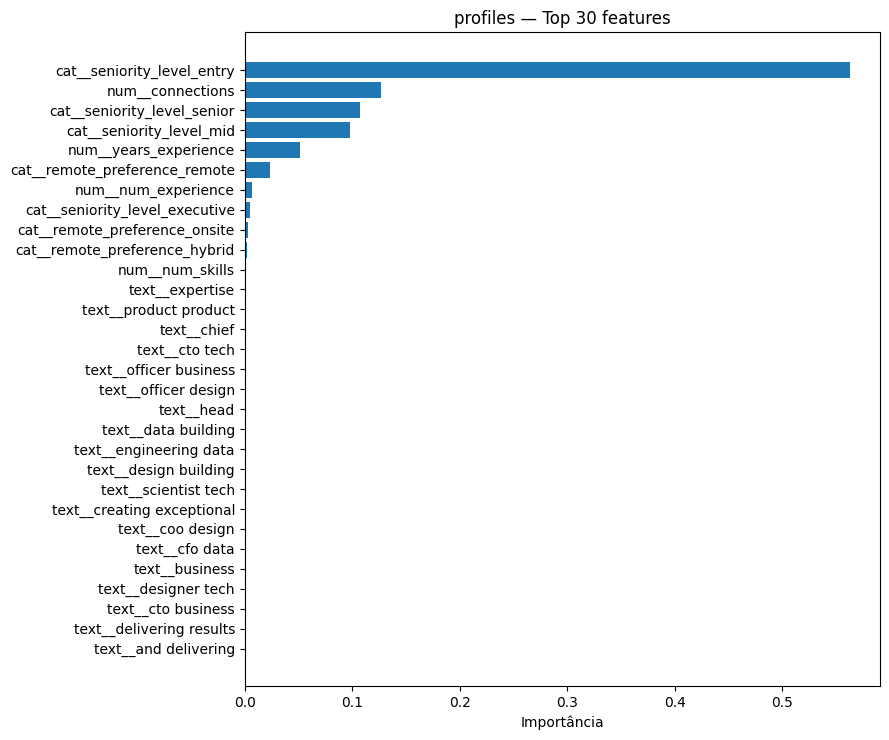

profiles: feature importance guardada em /home/miguellaptop/Secretária/ML/reports/profiles_feature_importance.csv


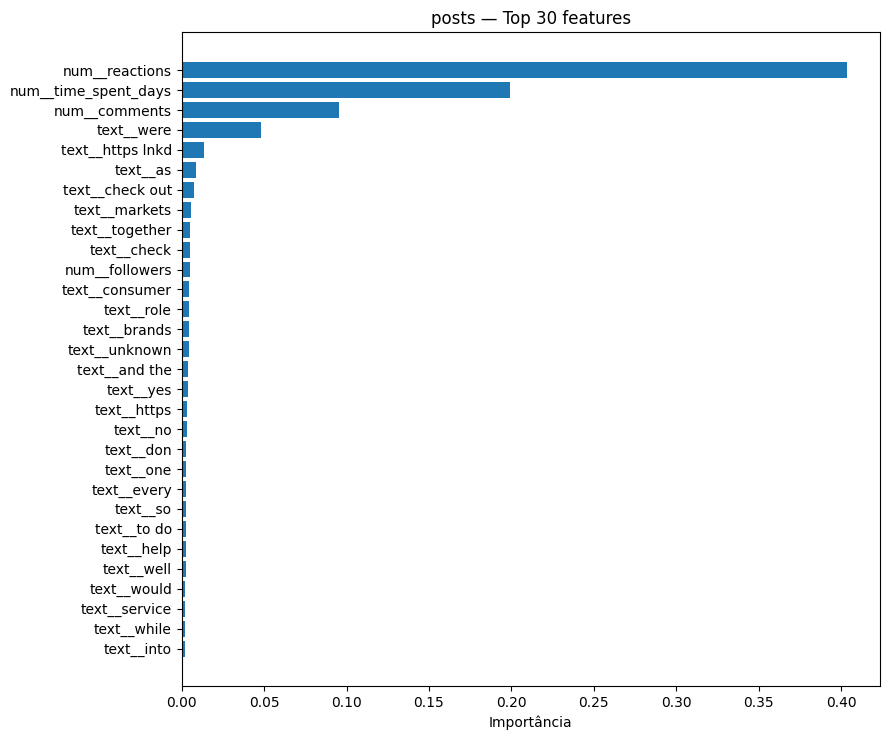

posts: feature importance guardada em /home/miguellaptop/Secretária/ML/reports/posts_feature_importance.csv

Top 10 features — profiles


,feature,importance
0,cat__seniority_level_entry,0.562999
1,num__connections,0.126661
2,cat__seniority_level_senior,0.107330
3,cat__seniority_level_mid,0.098424
4,num__years_experience,0.051153
5,cat__remote_preference_remote,0.023404
6,num__num_experience,0.007030
7,cat__seniority_level_executive,0.005016
8,cat__remote_preference_onsite,0.003046
9,cat__remote_preference_hybrid,0.001862



Top 10 features — posts


,feature,importance
0,num__reactions,0.403443
1,num__time_spent_days,0.198860
2,num__comments,0.095133
3,text__were,0.047870
4,text__https lnkd,0.013539
5,text__as,0.008498
6,text__check out,0.007556
7,text__markets,0.005400
8,text__together,0.005225
9,text__check,0.005122


In [11]:
# ============================================
# 10. Feature importance
# ============================================

def get_feature_names_from_pipeline(pipeline, X_sample):
    """Obtém nomes das features depois do preprocessamento."""
    preprocessor = pipeline.named_steps["preprocess"]

    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        transformed = preprocessor.transform(X_sample)
        return np.array([f"feature_{i}" for i in range(transformed.shape[1])])


def export_feature_importance(task_name, task, pipeline, top_n=30):
    """Exporta CSV e gráfico das features mais importantes."""
    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print(f"{task_name}: modelo sem feature_importances_.")
        return None

    feature_names = get_feature_names_from_pipeline(pipeline, task["X_val"].head(5))
    importances = model.feature_importances_

    if len(feature_names) != len(importances):
        feature_names = np.array([f"feature_{i}" for i in range(len(importances))])

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    output_csv = REPORTS_DIR / f"{task_name}_feature_importance.csv"
    importance_df.to_csv(output_csv, index=False)

    top = importance_df.head(top_n).sort_values("importance", ascending=True)

    plt.figure(figsize=(9, max(5, top_n * 0.25)))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Importância")
    plt.title(f"{task_name} — Top {top_n} features")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"{task_name}_feature_importance_top_{top_n}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print(f"{task_name}: feature importance guardada em {output_csv}")

    return importance_df


feature_importances = {}

for task_name, task in TASKS.items():
    feature_importances[task_name] = export_feature_importance(
        task_name=task_name,
        task=task,
        pipeline=final_models[task_name],
        top_n=30,
    )

for task_name, importance_df in feature_importances.items():
    if importance_df is not None:
        print(f"\nTop 10 features — {task_name}")
        display(importance_df.head(10))


## 11. Gráficos de validação

Se o notebook acabou de treinar, estes gráficos usam o modelo selecionado **antes do refit final**. Se o notebook carregou cache, são apenas um smoke-test visual.


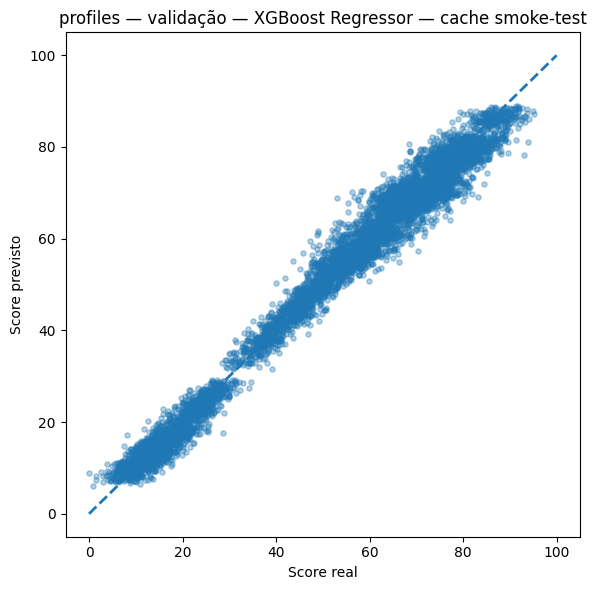

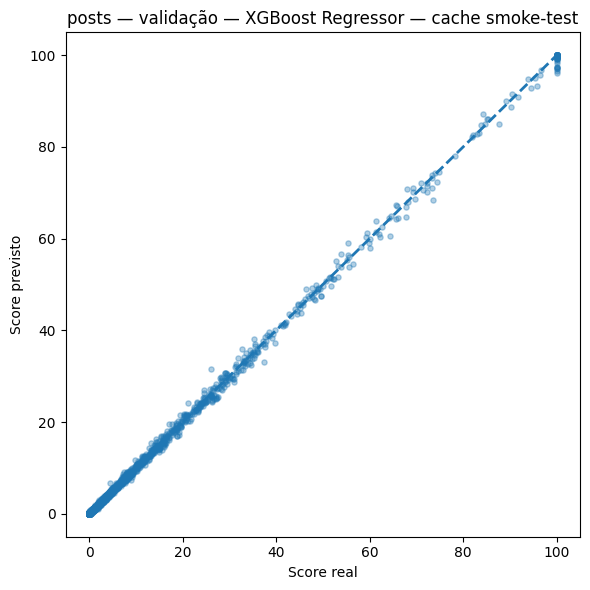

Gráficos guardados em reports/figures/.


In [12]:
# ============================================
# 11. Visualização das previsões
# ============================================

for task_name, task in TASKS.items():
    if SKIP_TRAINING:
        pipeline_for_plot = final_models[task_name]
        model_label = registry["tasks"][task_name]["selected_model"] + " — cache smoke-test"
    else:
        pipeline_for_plot = tuning_results[task_name]["selected_pipeline"]
        model_label = tuning_results[task_name]["selected_model_name"]

    val_pred = pipeline_for_plot.predict(task["X_val"])

    plot_predictions(
        task["y_val"],
        val_pred,
        f"{task_name} — validação — {model_label}",
        FIGURES_DIR / f"{task_name}_validation_actual_vs_predicted.png",
    )

print("Gráficos guardados em reports/figures/.")


## 12. Avaliação final no split de teste

Esta secção substitui o notebook separado `final_unseen_test`.

Aqui já **não há treino, tuning nem seleção de modelo**.  
A lógica é:

1. usar o `registry` e os modelos finais já criados/carregados;
2. confirmar que os SHA256 de treino/validação/metadata ainda batem certo;
3. carregar apenas os splits de teste;
4. preparar as mesmas features usadas no treino;
5. calcular métricas finais;
6. guardar métricas, previsões e gráficos.

Isto mantém o teste como avaliação final imparcial dentro do mesmo notebook.


In [13]:
# ============================================
# 12.1 Preparar e validar o teste final
# ============================================

def make_test_fingerprint():
    """Regista o SHA256 dos ficheiros de teste usados na avaliação final."""
    files = {
        "profiles_test": TEST_DIR / "profiles_test.csv",
        "posts_test": TEST_DIR / "posts_test.csv",
    }

    return {name: file_sha256(path) for name, path in files.items()}


def assert_final_models_ready():
    """Confirma que existem modelos finais e registry antes de tocar no teste."""
    if "final_models" not in globals() or not final_models:
        raise RuntimeError("final_models não existe. Executa primeiro as secções de treino/cache.")

    if "registry" not in globals() or not registry:
        raise RuntimeError("registry não existe. Executa primeiro a secção de refit/cache.")

    expected_tasks = {"profiles", "posts"}
    missing_models = expected_tasks - set(final_models.keys())
    missing_registry_tasks = expected_tasks - set(registry.get("tasks", {}).keys())

    if missing_models:
        raise RuntimeError(f"Modelos finais em falta: {sorted(missing_models)}")

    if missing_registry_tasks:
        raise RuntimeError(f"Tarefas em falta no registry: {sorted(missing_registry_tasks)}")


assert_final_models_ready()

# Confirma que o modelo carregado/treinado corresponde aos splits atuais.
registry_data_fingerprint = registry.get("fingerprints", {}).get("data")
fingerprint_check = fingerprint_comparison_df(registry_data_fingerprint, DATA_FINGERPRINT)

print("Verificação SHA256 antes do teste final:")
display(fingerprint_check)

sha_path = REPORTS_DIR / "final_test_sha256_training_validation_check.csv"
fingerprint_check.to_csv(sha_path, index=False)
print("Verificação SHA256 treino/validação guardada em:", sha_path)

changed_training_items = fingerprint_check.loc[
    fingerprint_check["status"] != "unchanged",
    "item",
].tolist()

if changed_training_items:
    raise RuntimeError(
        "Os splits/metadata de treino/validação mudaram desde o treino do modelo. "
        f"Itens alterados: {changed_training_items}. Volta a treinar antes de testar."
    )

TEST_FINGERPRINT = make_test_fingerprint()

test_fingerprint_df = pd.DataFrame([
    {"item": key, "sha256": value}
    for key, value in TEST_FINGERPRINT.items()
])

print("\nSHA256 dos ficheiros de teste usados nesta avaliação:")
display(test_fingerprint_df)

test_sha_path = REPORTS_DIR / "final_test_sha256_manifest.csv"
test_fingerprint_df.to_csv(test_sha_path, index=False)
print("Manifesto SHA256 do teste guardado em:", test_sha_path)


Verificação SHA256 antes do teste final:


,item,status,previous_sha256,current_sha256
0,metadata,unchanged,da00eccbe0171ba8a0e81c1f17fb3c76740da58d1e1251...,da00eccbe0171ba8a0e81c1f17fb3c76740da58d1e1251...
1,posts_train,unchanged,ac8fe6bef25dcd615feca51d522522b362586d205fa62b...,ac8fe6bef25dcd615feca51d522522b362586d205fa62b...
2,posts_validation,unchanged,267c4d7c55a9b8e967a117fbbcec36c28909592d5b624d...,267c4d7c55a9b8e967a117fbbcec36c28909592d5b624d...
3,profiles_train,unchanged,318a53155b7d14dab50eafc8e6275f3fe181f624f8fe6b...,318a53155b7d14dab50eafc8e6275f3fe181f624f8fe6b...
4,profiles_validation,unchanged,a024747837ca5e180d05750efbfaa0ed1f1c605c0f685c...,a024747837ca5e180d05750efbfaa0ed1f1c605c0f685c...


Verificação SHA256 treino/validação guardada em: /home/miguellaptop/Secretária/ML/reports/final_test_sha256_training_validation_check.csv

SHA256 dos ficheiros de teste usados nesta avaliação:


,item,sha256
0,profiles_test,d1a0c219489ab1a5703fcad9317f93a7088c24e9faedd7...
1,posts_test,61a29dba147ace9eb15251bc87009503df2283ba6e696b...


Manifesto SHA256 do teste guardado em: /home/miguellaptop/Secretária/ML/reports/final_test_sha256_manifest.csv


## 13. Preparar dados de teste

A preparação replica apenas o necessário da fase de treino:  
a feature textual `_text_all` e as mesmas features guardadas no `registry`.

Não há `fit` de preprocessamento aqui. O `Pipeline` carregado já sabe como transformar os dados.


In [14]:
# ============================================
# 13. Preparar X_test e y_test
# ============================================

def prepare_test_task(task_name):
    """Prepara X_test e y_test usando metadata + registry do modelo final."""
    if task_name not in split_metadata:
        raise KeyError(f"Metadata da tarefa '{task_name}' não existe.")

    if task_name not in registry.get("tasks", {}):
        raise KeyError(f"Tarefa '{task_name}' não existe no registry.")

    task_info = registry["tasks"][task_name]
    metadata_section = split_metadata[task_name]

    target_col = task_info.get("target") or metadata_section["target"]
    test_df = read_split(task_name, "test")

    text_columns = list_existing(test_df, metadata_section.get("text_columns", []))
    test_df = build_text_column(test_df, text_columns)

    if target_col not in test_df.columns:
        raise ValueError(f"Target em falta no teste de {task_name}: {target_col}")

    test_df[target_col] = pd.to_numeric(test_df[target_col], errors="coerce")

    if test_df[target_col].isna().any():
        raise ValueError(f"Target {target_col} tem valores em falta no teste de {task_name}.")

    feature_info = task_info.get("features", {})
    numeric_features = feature_info.get("numeric_features", [])
    categorical_features = feature_info.get("categorical_features", [])
    text_feature = feature_info.get("text_feature", "_text_all")

    feature_columns = numeric_features + categorical_features + [text_feature]
    missing_features = [col for col in feature_columns if col not in test_df.columns]

    if missing_features:
        raise ValueError(f"Features em falta no teste de {task_name}: {missing_features}")

    X_test = test_df[feature_columns].copy()
    y_test = test_df[target_col].copy()

    print(f"\n{task_name} — teste")
    print("Target:", target_col)
    print("Features usadas:", feature_columns)
    print("Shape X_test:", X_test.shape)

    return {
        "name": task_name,
        "target": target_col,
        "X_test": X_test,
        "y_test": y_test,
        "raw_test": test_df,
        "feature_columns": feature_columns,
    }


TEST_TASKS = {
    "profiles": prepare_test_task("profiles"),
    "posts": prepare_test_task("posts"),
}



profiles — teste
Target: profile_discoverability_score
Features usadas: ['connections', 'years_experience', 'about_length', 'headline_length', 'num_skills', 'num_experience', 'seniority_level', 'industry', 'remote_preference', '_text_all']
Shape X_test: (7500, 10)

posts — teste
Target: post_discoverability_score
Features usadas: ['followers', 'reactions', 'comments', 'num_hashtags', 'content_length', 'num_links', 'time_spent_days', 'media_type', 'hashtags_bin', '_text_all']
Shape X_test: (5102, 10)


## 14. Métricas finais no teste

Estas são as métricas finais mais honestas do projeto, porque o teste não participou na escolha do algoritmo nem no tuning dos hiperparâmetros.


In [15]:
# ============================================
# 14. Avaliação final no teste
# ============================================

def predict_and_evaluate_test(task_name):
    """Gera previsões e métricas finais para uma tarefa."""
    model = final_models[task_name]
    task = TEST_TASKS[task_name]
    task_info = registry["tasks"][task_name]

    y_pred_raw = model.predict(task["X_test"])
    y_pred = np.clip(y_pred_raw, 0, 100)

    metrics = regression_metrics(task["y_test"], y_pred)

    return {
        "task": task_name,
        "target": task["target"],
        "selected_model": task_info.get("selected_model"),
        "selected_stage": task_info.get("selected_stage"),
        "final_training_rows": task_info.get("final_training_rows"),
        "test_rows": int(len(task["y_test"])),
        "MAE": float(metrics["MAE"]),
        "RMSE": float(metrics["RMSE"]),
        "R2": float(metrics["R2"]),
        "y_pred": y_pred,
        "y_pred_raw": y_pred_raw,
    }


test_evaluation_results = {
    "profiles": predict_and_evaluate_test("profiles"),
    "posts": predict_and_evaluate_test("posts"),
}

final_test_metrics = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in ["y_pred", "y_pred_raw"]
    }
    for result in test_evaluation_results.values()
]).sort_values("task")

print("Métricas finais no split de teste:")
display(final_test_metrics)

final_metrics_path = REPORTS_DIR / "final_test_metrics_model_A.csv"
final_test_metrics.to_csv(final_metrics_path, index=False)
final_test_metrics.to_csv(REPORTS_DIR / "final_test_metrics.csv", index=False)

print("Métricas finais guardadas em:")
print("-", final_metrics_path)
print("-", REPORTS_DIR / "final_test_metrics.csv")


Métricas finais no split de teste:


,task,target,selected_model,selected_stage,final_training_rows,test_rows,MAE,RMSE,R2
1,posts,post_discoverability_score,XGBoost Regressor,tuned,28910,5102,0.258598,0.943304,0.996186
0,profiles,profile_discoverability_score,XGBoost Regressor,base_after_tuning_check,42500,7500,2.585138,3.356406,0.980649


Métricas finais guardadas em:
- /home/miguellaptop/Secretária/ML/reports/final_test_metrics_model_A.csv
- /home/miguellaptop/Secretária/ML/reports/final_test_metrics.csv


## 15. Comparar validação vs. teste

Esta tabela mostra se o desempenho final se manteve próximo da validação.  
Se o teste ficar muito pior, pode haver overfitting ou diferença de distribuição entre validação e teste.


In [16]:
# ============================================
# 15. Comparação validação vs teste
# ============================================

def validation_metrics_from_registry(task_name):
    """Extrai métricas de validação antes do refit final a partir do registry."""
    task_info = registry["tasks"][task_name]
    metrics = task_info.get("validation_metrics_before_final_refit", {})

    return {
        "task": task_name,
        "selected_model": task_info.get("selected_model"),
        "selected_stage": task_info.get("selected_stage"),
        "validation_MAE": metrics.get("MAE"),
        "validation_RMSE": metrics.get("RMSE"),
        "validation_R2": metrics.get("R2"),
    }


validation_summary = pd.DataFrame([
    validation_metrics_from_registry("profiles"),
    validation_metrics_from_registry("posts"),
])

test_summary = final_test_metrics.rename(columns={
    "MAE": "test_MAE",
    "RMSE": "test_RMSE",
    "R2": "test_R2",
})[
    [
        "task",
        "selected_model",
        "selected_stage",
        "test_rows",
        "test_MAE",
        "test_RMSE",
        "test_R2",
    ]
]

validation_vs_test = validation_summary.merge(
    test_summary,
    on=["task", "selected_model", "selected_stage"],
    how="left",
)

validation_vs_test["MAE_gap_test_minus_validation"] = (
    validation_vs_test["test_MAE"] - validation_vs_test["validation_MAE"]
)

validation_vs_test["RMSE_gap_test_minus_validation"] = (
    validation_vs_test["test_RMSE"] - validation_vs_test["validation_RMSE"]
)

validation_vs_test["R2_gap_test_minus_validation"] = (
    validation_vs_test["test_R2"] - validation_vs_test["validation_R2"]
)

print("Comparação validação vs teste:")
display(validation_vs_test)

validation_vs_test_path = REPORTS_DIR / "validation_vs_final_test_model_A.csv"
validation_vs_test.to_csv(validation_vs_test_path, index=False)

print("Comparação validação vs teste guardada em:", validation_vs_test_path)


Comparação validação vs teste:


,task,selected_model,selected_stage,validation_MAE,validation_RMSE,validation_R2,test_rows,test_MAE,test_RMSE,test_R2,MAE_gap_test_minus_validation,RMSE_gap_test_minus_validation,R2_gap_test_minus_validation
0,profiles,XGBoost Regressor,base_after_tuning_check,2.582956,3.360175,0.980505,7500,2.585138,3.356406,0.980649,0.002182,-0.003769,0.000144
1,posts,XGBoost Regressor,tuned,0.294023,1.182344,0.993382,5102,0.258598,0.943304,0.996186,-0.035424,-0.239040,0.002804


Comparação validação vs teste guardada em: /home/miguellaptop/Secretária/ML/reports/validation_vs_final_test_model_A.csv


## 16. Guardar previsões e gráficos finais

Estes ficheiros servem como evidência para o relatório e para a apresentação.


profiles: previsões guardadas em /home/miguellaptop/Secretária/ML/reports/profiles_final_test_predictions_model_A.csv


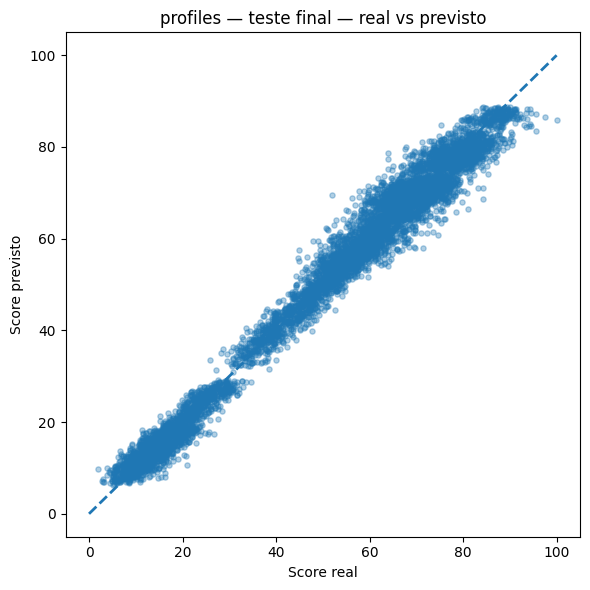

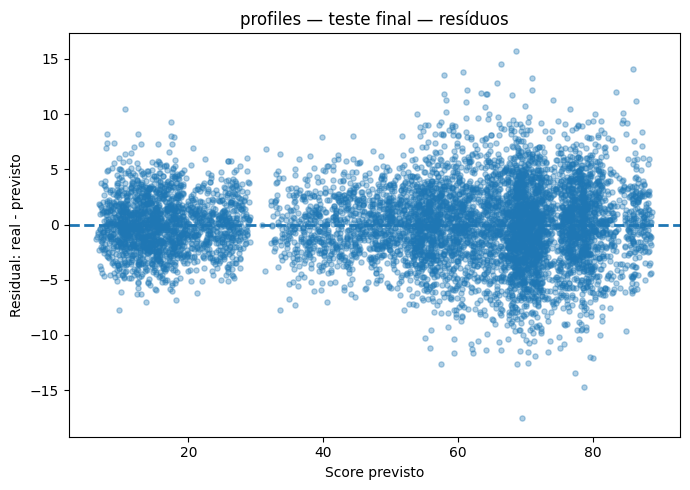

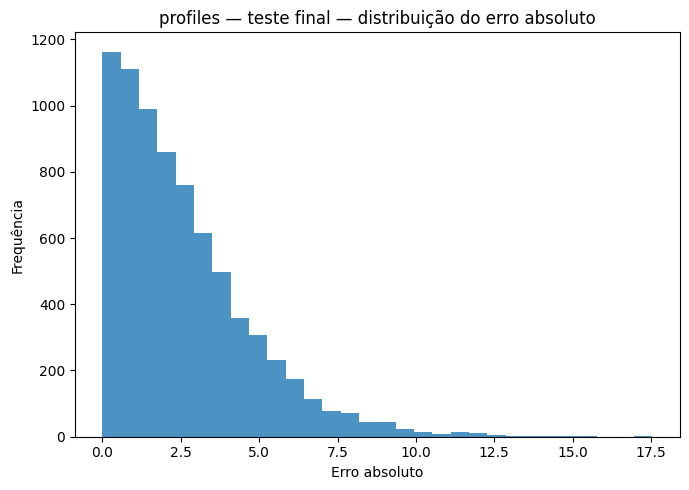

posts: previsões guardadas em /home/miguellaptop/Secretária/ML/reports/posts_final_test_predictions_model_A.csv


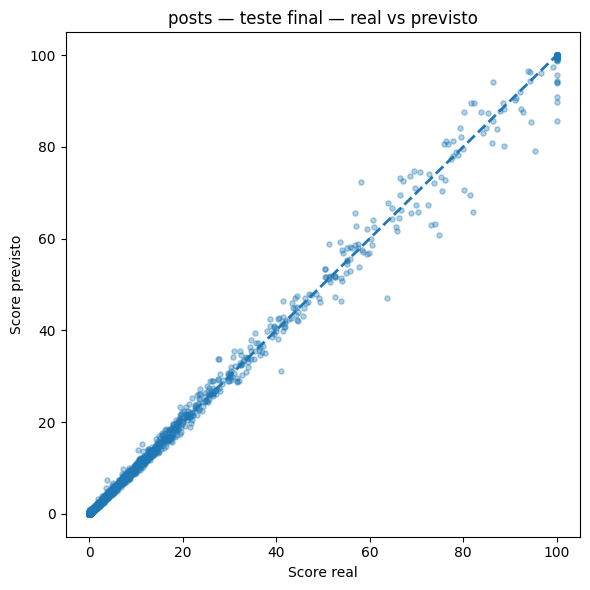

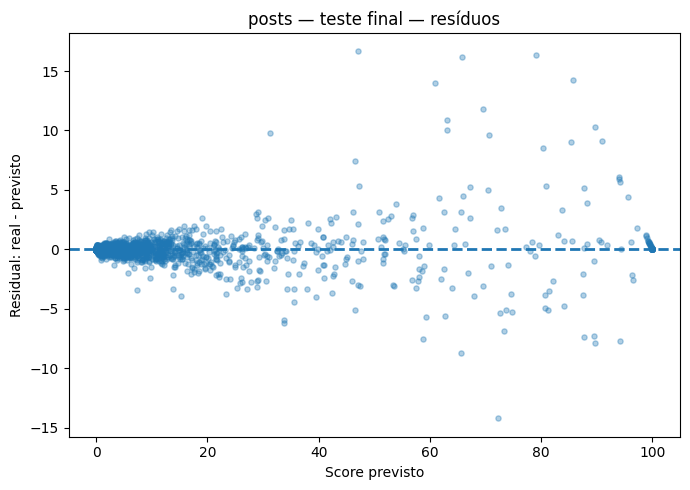

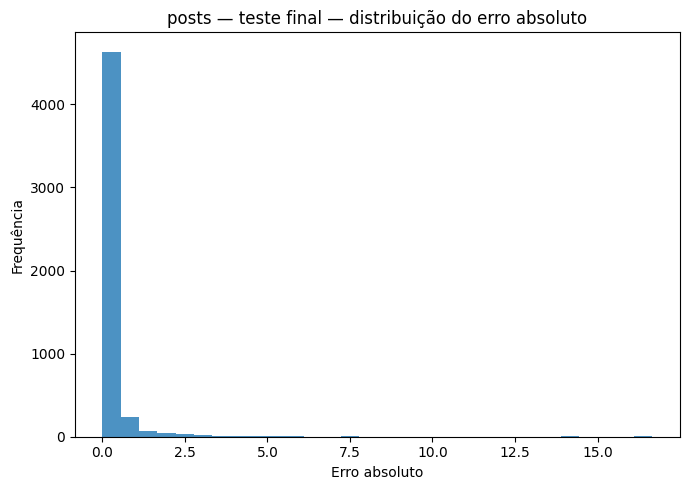

Previsões e gráficos finais guardados.


In [17]:
# ============================================
# 16. Previsões e gráficos finais
# ============================================

def save_test_predictions(task_name):
    """Guarda previsões finais com erro absoluto e residual."""
    task = TEST_TASKS[task_name]
    result = test_evaluation_results[task_name]

    y_true = task["y_test"].reset_index(drop=True)
    y_pred = pd.Series(result["y_pred"], name="y_pred")
    y_pred_raw = pd.Series(result["y_pred_raw"], name="y_pred_raw")

    predictions = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_raw": y_pred_raw,
    })

    predictions["residual"] = predictions["y_true"] - predictions["y_pred"]
    predictions["absolute_error"] = predictions["residual"].abs()

    predictions = predictions.sort_values("absolute_error", ascending=False).reset_index(drop=True)

    output_path = REPORTS_DIR / f"{task_name}_final_test_predictions_model_A.csv"
    predictions.to_csv(output_path, index=False)

    print(f"{task_name}: previsões guardadas em {output_path}")

    return predictions


def plot_residuals(y_true, y_pred, title, output_path):
    """Gráfico de resíduos."""
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.35, s=14)
    plt.axhline(0, linestyle="--", linewidth=2)
    plt.xlabel("Score previsto")
    plt.ylabel("Residual: real - previsto")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def plot_absolute_error_distribution(predictions, title, output_path):
    """Histograma do erro absoluto."""
    plt.figure(figsize=(7, 5))
    plt.hist(predictions["absolute_error"], bins=30, alpha=0.80)
    plt.xlabel("Erro absoluto")
    plt.ylabel("Frequência")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


test_predictions = {}

for task_name, task in TEST_TASKS.items():
    result = test_evaluation_results[task_name]
    y_pred = result["y_pred"]

    predictions = save_test_predictions(task_name)
    test_predictions[task_name] = predictions

    plot_predictions(
        task["y_test"],
        y_pred,
        f"{task_name} — teste final — real vs previsto",
        FIGURES_DIR / f"{task_name}_final_test_actual_vs_predicted_model_A.png",
    )

    plot_residuals(
        task["y_test"],
        y_pred,
        f"{task_name} — teste final — resíduos",
        FIGURES_DIR / f"{task_name}_final_test_residuals_model_A.png",
    )

    plot_absolute_error_distribution(
        predictions,
        f"{task_name} — teste final — distribuição do erro absoluto",
        FIGURES_DIR / f"{task_name}_final_test_absolute_error_distribution_model_A.png",
    )

print("Previsões e gráficos finais guardados.")


## 17. Interpretação curta para relatório/apresentação

A célula abaixo imprime uma leitura simples do resultado final.


In [18]:
# ============================================
# 17. Interpretação curta
# ============================================

for _, row in validation_vs_test.iterrows():
    print("=" * 90)
    print(f"Tarefa: {row['task']}")
    print(f"Modelo final: {row['selected_model']} ({row['selected_stage']})")
    print(f"MAE validação: {row['validation_MAE']:.2f}")
    print(f"MAE teste:     {row['test_MAE']:.2f}")
    print(f"Gap MAE teste - validação: {row['MAE_gap_test_minus_validation']:.2f}")

    gap = row["MAE_gap_test_minus_validation"]

    if pd.isna(gap):
        print("Interpretação: não foi possível calcular o gap.")
    elif gap > 3:
        print("Interpretação: o teste ficou bastante pior do que a validação; possível overfitting ou diferença de distribuição.")
    elif gap < -3:
        print("Interpretação: o teste ficou melhor do que a validação; o teste pode ser mais fácil ou menos ruidoso.")
    else:
        print("Interpretação: validação e teste estão relativamente próximos; sinal razoável de generalização.")

print("\nConclusão geral:")
print("- O teste foi usado apenas no fim.")
print("- O teste não serviu para escolher algoritmo nem hiperparâmetros.")
print("- As métricas finais a reportar estão em reports/final_test_metrics_model_A.csv.")


Tarefa: profiles
Modelo final: XGBoost Regressor (base_after_tuning_check)
MAE validação: 2.58
MAE teste:     2.59
Gap MAE teste - validação: 0.00
Interpretação: validação e teste estão relativamente próximos; sinal razoável de generalização.
Tarefa: posts
Modelo final: XGBoost Regressor (tuned)
MAE validação: 0.29
MAE teste:     0.26
Gap MAE teste - validação: -0.04
Interpretação: validação e teste estão relativamente próximos; sinal razoável de generalização.

Conclusão geral:
- O teste foi usado apenas no fim.
- O teste não serviu para escolher algoritmo nem hiperparâmetros.
- As métricas finais a reportar estão em reports/final_test_metrics_model_A.csv.


## Conclusão do notebook 03

Este notebook cumpre o papel de treino, comparação, otimização e avaliação final porque:

- carrega os splits do notebook anterior;
- evita data leakage com `Pipeline`;
- compara dois algoritmos reais;
- inclui baseline simples;
- faz tuning de hiperparâmetros;
- escolhe o melhor modelo por MAE na validação;
- re-treina o modelo final com treino + validação;
- guarda modelos, métricas, tuning e feature importance;
- reutiliza modelos existentes quando os splits/configuração não mudaram;
- regista SHA256 dos splits/metadata para justificar quando o treino tem de ser repetido;
- regista se cada treino usa CPU ou GPU;
- usa o split de teste apenas no fim, como avaliação final imparcial.

Frase útil para o relatório:

> Foram comparados dois algoritmos de regressão, Random Forest e XGBoost, usando MAE como métrica principal por o target estar numa escala de 0 a 100. Para uma comparação mais justa, ambos os algoritmos foram sujeitos a tuning com RandomizedSearchCV. O melhor modelo foi escolhido pelo menor MAE no conjunto de validação e depois re-treinado com treino + validação. Só no fim foi usado o split de teste, separado desde a preparação dos dados, para calcular as métricas finais de generalização. A reutilização de modelos treinados foi controlada por fingerprints SHA256 dos splits/metadata e da configuração de treino; quando estes mudam, o cache é invalidado e o treino é repetido.
